# Malware Family classification using MAML.

  - Author: Jihoon Shin (University of Texas at El Paso)

In [2]:
import pickle
import random
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torch import nn
import torch.nn.functional as F
from collections import OrderedDict
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import copy
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm

%matplotlib inline

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Load the object from a file
with open('document_vectors_with_labels_all_samples.pkl', 'rb') as file:
    loaded_data = pickle.load(file)
    print("Data Loaded.")

class_samples = {}  # To check the samples of the classes.
for item in loaded_data:
    label = item['label']
    vector = item['vector']

    if label in class_samples:
        class_samples[label].append(vector)
    else:
        class_samples[label] = [vector]

Data Loaded.


In [6]:
''' Checking the data. '''
for label, vectors in class_samples.items():
    print(f"Label: {label}")
    print(f"Vector: {vectors[0]}")  # sample

Label: njRAT
Vector: [ 0.99529237 -1.0887798  -2.7544866   2.72095     1.3012339   0.39843708
  0.92153764  1.7870907  -1.0570626  -0.08142632  0.7198944   0.20867454
 -0.65400606 -0.5882709  -2.2318003  -0.6627837   0.11260171  2.1408126
 -1.3319998  -1.3215463  -1.6051924   1.9671223   0.8701105  -0.6009053
 -1.123431   -0.20793846 -0.9592163   1.8478392  -1.3176376   0.9137097
  1.5159534  -0.06079344 -1.7624245  -1.0045584   0.31324637 -0.48271364
 -2.0405264  -1.0286548   1.5181797  -0.9857117   2.219497   -1.416948
 -0.8202796  -0.5938592  -0.83724445 -0.66163594 -0.47387728 -2.7942834
  1.4377106  -1.4935328 ]
Label: Swisyn
Vector: [-1.3627586  -1.0523919  -1.8684176   0.20055969 -0.09194414 -1.635279
  1.3597172   0.2821116  -2.2948344  -0.3404957  -0.11137538  0.9732243
  0.17591219 -0.71394175 -1.0421933   1.4523771  -0.16258186  1.8672597
 -1.3191352  -1.8531157  -0.21109207  0.70964336  1.3470775   0.68350905
 -0.06265773  0.17040461 -2.0968468   0.15845406 -0.60017943  0.1

In [15]:
# class for the Training Task & Testing Task
class MetaTrainingTask(object):
  def __init__(self, train_dataset, training_classes, num_sampled_class_training, num_sample_per_class, num_support_instances, num_query_instances, mode):
    self.train_dataset = train_dataset  # part of loaded_data which only has classes for training.
    self.num_classes = num_sampled_class_training  # number of classes in each task
    self.num_support_instances = num_support_instances  # number of instances per class in the support set
    self.num_query_instances = num_query_instances  # number of instances per class in the query set
    self.support_vectors = []
    self.support_labels = []
    self.query_vectors = []
    self.query_labels = []

    sampled_classes = random.sample(training_classes, self.num_classes)  # sample classes for training
    if mode == 'verbose':
      print("MetaTrainingTask - sampled classes: ", sampled_classes)

    for label in sampled_classes:
      samples = [item['vector'] for item in self.train_dataset if item['label'] == label]

      if len(samples) < num_sample_per_class:
        raise ValueError(f"[MetaTraining] Not enough samples for class {label}, ({len(samples)}).")
      sample_idxs = np.random.choice(len(samples), num_sample_per_class, replace=False)  # randomly shuffle and get sample as num_sample_per_class

      # support_samples: used for training (inner loop in MAML).
      support_samples = sample_idxs[:self.num_support_instances]
      # query_samples: use to evaluate the model's performance on that specific task.
      query_samples = sample_idxs[self.num_support_instances:self.num_support_instances + num_query_instances]

      if mode == 'verbose':
        print(f"  - Samples for [{label}] count: {len(sample_idxs)} = support_samples: {len(support_samples)} + query_samples: {len(query_samples)}")

      # Used in the inner loop.
      self.support_vectors.append(torch.tensor([samples[i] for i in support_samples], dtype=torch.float32))
      self.support_labels.extend([label] * len(support_samples))

      # Used in the outer loop (meta-training).
      self.query_vectors.append(torch.tensor([samples[i] for i in query_samples], dtype=torch.float32))
      self.query_labels.extend([label] * len(query_samples))

    # Convert lists to tensors
    self.support_vectors = torch.cat(self.support_vectors, dim=0)
    self.support_labels = torch.tensor(self.support_labels, dtype=torch.long)
    self.query_vectors = torch.cat(self.query_vectors, dim=0)
    self.query_labels = torch.tensor(self.query_labels, dtype=torch.long)

    if mode == 'verbose':
      print(f"  > support_vector: {len(self.support_vectors)}, support_labels: {len(self.support_labels)} | query_vector: {len(self.query_vectors)} / query_labels: {len(self.query_labels)}")

  def __len__(self):
    return len(self.query_labels)

  def __getitem__(self, idx):
    return self.query_vectors[idx], self.query_labels[idx]

# generates test tasks for evaluating the model after training.
class MetaTestingTask(object):
  def __init__(self, test_dataset, testing_classes, num_sampled_class_testing, num_sample_per_class, num_support_instances, num_query_instances, mode):
    self.test_dataset = test_dataset  # part of loaded_data which only has classes for testing.
    self.num_classes = num_sampled_class_testing
    self.num_support_instances = num_support_instances  # number of instances per class in the support set
    self.num_query_instances = num_query_instances  # number of instances per class in the query set
    self.support_vectors = []
    self.support_labels = []
    self.query_vectors = []
    self.query_labels = []

    sampled_classes = random.sample(testing_classes, self.num_classes)  # sample classes for testing
    if mode == 'verbose':
      print("MetaTestingTask - sampled classes: ", sampled_classes)

    for label in sampled_classes:
      samples = [item['vector'] for item in self.test_dataset if item['label'] == label]

      if len(samples) < num_sample_per_class:
        raise ValueError(f"[MetaTesting] Not enough samples for class {label}, ({len(samples)}).")
      sample_idxs = np.random.choice(len(samples), num_sample_per_class, replace=False)  # randomly shuffle and select

      # support_samples: use to adapt the model to the new task.
      support_samples = sample_idxs[:self.num_support_instances]
      # query_samples: use to evaluate the model's performance on this task after adaptation.
      query_samples = sample_idxs[self.num_support_instances:self.num_support_instances + self.num_query_instances]
      if mode == 'verbose':
        print(f"  - Samples for [{label}] count: {len(sample_idxs)} = support_samples: {len(support_samples)} + query_samples: {len(query_samples)}")

      # Used for quick adaptation in the testing phase.
      self.support_vectors.append(torch.tensor([samples[i] for i in support_samples], dtype=torch.float32))
      self.support_labels.extend([label] * len(support_samples))

      # Used to evaluate the model's performance on new tasks.
      self.query_vectors.append(torch.tensor([samples[i] for i in query_samples], dtype=torch.float32))
      self.query_labels.extend([label] * len(query_samples))

    # Convert lists to tensors
    self.support_vectors = torch.cat(self.support_vectors, dim=0)
    self.support_labels = torch.tensor(self.support_labels, dtype=torch.long)
    self.query_vectors = torch.cat(self.query_vectors, dim=0)
    self.query_labels = torch.tensor(self.query_labels, dtype=torch.long)

    if mode == 'verbose':
      print(f"  > support_vector: {len(self.support_vectors)}, support_labels: {len(self.support_labels)} | query_vector: {len(self.query_vectors)} / query_labels: {len(self.query_labels)}")

  def __len__(self):
    return len(self.query_labels)

  def __getitem__(self, idx):
    return self.query_vectors[idx], self.query_labels[idx]

In [16]:
''' BaseNet with 3-layers '''
class BaseNet(nn.Module):
  def __init__(self, num_classes):
    super(BaseNet, self).__init__()

    self.fc1 = nn.Linear(50,128)
    self.fc2 = nn.Linear(128, 64)  # Additional hidden layer
    self.fc3 = nn.Linear(64, num_classes)  # Output layer


  def forward(self, x, weight=None):
    if weight is None:
            x = F.relu(self.fc1(x))  # Apply ReLU activation
            x = F.relu(self.fc2(x))
            x = self.fc3(x)  # Output layer
    else:
        x = F.linear(x, weight['fc1.weight'], weight['fc1.bias'])
        x = F.relu(x)
        x = F.linear(x, weight['fc2.weight'], weight['fc2.bias'])
        x = F.relu(x)
        x = F.linear(x, weight['fc3.weight'], weight['fc3.bias'])

    return x

In [17]:
# Meta Learner
class MAML(nn.Module):
  def __init__(self, model, inner_lr, outer_lr, num_inner_steps, mode):
    super(MAML, self).__init__()
    self.model = model
    self.inner_lr = inner_lr  # learning rate for Inner loop updates
    self.outer_lr = outer_lr  # learning rate for Outer loop updates
    self.num_inner_steps = num_inner_steps  # number of steps for Inner loop updates
    self.optimizer = torch.optim.Adam(self.model.parameters(), lr=self.outer_lr)
    self.mode = mode

  # Inner Loop (Task-Specific Training)
  def inner_loop(self, support_vectors, support_labels):
    task_loss_fn = nn.CrossEntropyLoss()

    # Clone current weights (to avoid modifying the main model)
    temp_model = {name: param.clone() for name, param in self.model.named_parameters()}

    for _ in range(self.num_inner_steps):
      # Forward pass with fast weights
      preds = self.model(support_vectors, weight=temp_model)
      loss = task_loss_fn(preds, support_labels)

      # Compute gradients with respect to current fast weights
      grads = torch.autograd.grad(loss, temp_model.values(), create_graph=True)

      # Perform gradient update on fast weights
      temp_model = {name: param - self.inner_lr * grad for (name, param), grad in
                      zip(temp_model.items(), grads)}

    return temp_model  # Return the fast weights

  # Outer Loop (Meta-Update)
  def outer_loop(self, meta_tasks):
    total_loss = 0
    total_accuracy = 0
    cnt = 0 # for log

    for task in meta_tasks:
      # [Module Test] Log the loss value
      if self.mode == 'verbose_maml':
        initial_predictions = self.model(task.support_vectors)
        initial_loss = F.cross_entropy(initial_predictions, task.support_labels)

      temp_model = self.inner_loop(task.support_vectors, task.support_labels)
      # predictions = temp_model(task.query_vectors)  # old version
      predictions = self.model(task.query_vectors, weight=temp_model) # new version
      loss = F.cross_entropy(predictions, task.query_labels)

      total_loss += loss

      correct_preds = (torch.argmax(predictions, dim=1) == task.query_labels).float()
      accuracy = correct_preds.mean().item()
      total_accuracy += accuracy

      if self.mode == 'verbose_maml':
        print(f"[Outer Loop({cnt}/{len(meta_tasks)})] Initial Loss: {initial_loss.item()}, Final Loss: {loss.item()} | total loss= {total_loss}")  # for log
        cnt += 1 # for log

    total_loss /= len(meta_tasks)
    total_accuracy /= len(meta_tasks)

    if self.mode == 'verbose_maml':
      print(f"[Outer Loop] Total Loss: {total_loss}")

    self.optimizer.zero_grad()  # set the gradients to zero before starting to do backpropagation.
    total_loss.backward() # Compute gradients with respect to the main model's parameters

    if self.mode == 'verbose_maml':
      for name, param in self.model.named_parameters(): # code to check
        print(f"Parameter: {name}, Values: {param.data}")
        if param.grad is not None:
            grad_norm = param.grad.norm()
            print(f'Gradient norm for {name}: {grad_norm}')
        else:
            print(f'No gradients computed for {name}')

    self.optimizer.step() # applies the computed gradients to update the model's parameters
    return total_loss, total_accuracy

  def evaluate(self, task):
    temp_model = self.inner_loop(task.support_vectors, task.support_labels)
    predictions = self.model(task.query_vectors, weight=temp_model) # new version
    loss = F.cross_entropy(predictions, task.query_labels)

    # compute accuracy
    predicted_labels = torch.argmax(predictions, dim=1)
    corrected_predictions = (predicted_labels == task.query_labels).sum().item()
    accuracy = corrected_predictions / len(task.query_labels)

    return loss.item(), accuracy

In [18]:
''' --- [Set the number of classes and Split the dataset] --- '''
num_classes = len(class_samples)  # Number of unique malware families
num_classes_training = 7  # Number of classes for training
num_classes_testing = num_classes - num_classes_training # Number of classes for testing

# Split the classes into Training and Testing
training_classes = random.sample(list(class_samples), num_classes_training) # dataset for the training
testing_classes = [label for label in class_samples if label not in training_classes] # dataset for the testing which is not in training_classes

# Fit LabelEncoder on ALL classes (training + testing) to ensure consistent encoding
all_labels = training_classes + testing_classes
print(all_labels)
label_encoder = LabelEncoder()
label_encoder.fit(all_labels)

training_classes_encoded = label_encoder.transform(training_classes).tolist()
testing_classes_encoded = label_encoder.transform(testing_classes).tolist()

print(f"label_encoder.classes_): {label_encoder.classes_}")
print(f"Encoded Training Classes: {training_classes_encoded}")
print(f"Encoded Testing Classes: {testing_classes_encoded}")

# Encode labels and split data
meta_training_data = []
meta_testing_data = []

for item in loaded_data:
  encoded_label = label_encoder.transform([item['label']])[0]  # Encode label
  encoded_item = {'label': encoded_label, 'vector': item['vector']}  # Replace original label

  if item['label'] in training_classes:
      meta_training_data.append(encoded_item)
  elif item['label'] in testing_classes:
      meta_testing_data.append(encoded_item)

print(f"Unique num_classes: {num_classes} (classes for training: {num_classes_training} / for testing: {num_classes_testing})")
print(f"Total number of Loaded data: {len(loaded_data)}")
print(f"* MetaTraining:")
print(f"  - Sampled Classes for MetaTrainingTask: {len(training_classes)} = {training_classes}")
print(f"  - number of MetaTraining data: {len(meta_training_data)}")
print(f"* MetaTesting:")
print(f"  - Sampled Classes for MetaTestingTask: {len(testing_classes)} = {testing_classes}")
print(f"  - number of MetaTesting data: {len(meta_testing_data)}")

['HarHar', 'Swisyn', 'Trickbot', 'Adload', 'Lokibot', 'Ursnif', 'Qakbot', 'njRAT', 'Emotet', 'Zeus']
label_encoder.classes_): ['Adload' 'Emotet' 'HarHar' 'Lokibot' 'Qakbot' 'Swisyn' 'Trickbot'
 'Ursnif' 'Zeus' 'njRAT']
Encoded Training Classes: [2, 5, 6, 0, 3, 7, 4]
Encoded Testing Classes: [9, 1, 8]
Unique num_classes: 10 (classes for training: 7 / for testing: 3)
Total number of Loaded data: 48976
* MetaTraining:
  - Sampled Classes for MetaTrainingTask: 7 = ['HarHar', 'Swisyn', 'Trickbot', 'Adload', 'Lokibot', 'Ursnif', 'Qakbot']
  - number of MetaTraining data: 28581
* MetaTesting:
  - Sampled Classes for MetaTestingTask: 3 = ['njRAT', 'Emotet', 'Zeus']
  - number of MetaTesting data: 20395


In [19]:
''' --- [▶ Printing the process to check the process] --- '''
# 1) for checkging Tasks part: verbose
# mode = 'verbose'
# 2) for checking MAML class part: verbose_maml
# mode = 'verbose_maml'
# 3) for just printing the loss and accuracy information
mode = 'normal'
''' --------------------------------------------------------- '''
''' --- [Set the hyperparameters] --- '''
inner_lr = 0.01  # Learning rate for inner loop
outer_lr = 0.001  # Learning rate for outer loop

num_sampled_class_training = 5 # 5 classes will be sampled from the 7 (num_classes_training) classes in Training Task class.
num_sampled_class_testing = 2 # 2 classes will be sampled from the 3 (num_classes_testing) classes in Testing Task class.

num_meta_tasks = 5         # Number of meta-training & meta-testing tasks per epoch (Increased from 20)
num_inner_steps = 40       # Number of inner loop steps (Increased from 10)
num_epochs = 50             # Number of meta-training epochs (Increased from 100)

num_samples_per_class = 15 # Number of samples per class
num_support_instances = 5  # Number of support instances per class
num_query_instances = 10  # Number of query instances per class

# Initialize the model and MAML
model = BaseNet(num_classes)
print(model)
maml = MAML(model, inner_lr, outer_lr, num_inner_steps, mode)

BaseNet(
  (fc1): Linear(in_features=50, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)


In [20]:
''' Checking the model. '''
meta_loss_list = []
meta_acc_list = []
val_loss_list = []
val_acc_list = []

for epoch in range(num_epochs):
  # generate meta-training tasks
  meta_tasks = [MetaTrainingTask(meta_training_data, training_classes_encoded, num_sampled_class_training, num_samples_per_class, num_support_instances, num_query_instances, mode) for _ in range(num_meta_tasks)]

  if mode in ('verbose', 'verbose_maml'):
    print(f"number of meta_tasks: {len(meta_tasks)}")

  # perform meta-training
  meta_loss, meta_acc = maml.outer_loop(meta_tasks)
  # if (epoch+1) % 10 == 0:
  # print(f'Epoch {(epoch+1)}/{num_epochs}, Meta Loss: {meta_loss.item()}')

  meta_loss_list.append(meta_loss)
  meta_acc_list.append(meta_acc)
  # Compute change direction for loss and accuracy
  if len(meta_loss_list) > 1:
      loss_trend = "↑" if meta_loss > meta_loss_list[-2] else "↓"
      acc_trend = "↑" if meta_acc > meta_acc_list[-2] else "↓"
  else:
      loss_trend = acc_trend = "-"

  print(f'Epoch {(epoch+1)}/{num_epochs}, Meta Loss: {meta_loss:.8f} {loss_trend}, Meta Accuracy: {meta_acc:.2f} {acc_trend} ')

  # validation
  meta_testing_tasks = [MetaTestingTask(meta_testing_data, testing_classes_encoded, num_sampled_class_testing, num_samples_per_class, num_support_instances, num_query_instances, mode) for _ in range(num_meta_tasks)]
  total_test_loss = 0
  total_test_acc = 0

  for task in meta_testing_tasks:
    test_loss, test_acc = maml.evaluate(task)
    total_test_loss += test_loss
    total_test_acc += test_acc

  avg_test_loss = total_test_loss / len(meta_testing_tasks)
  avg_test_acc = total_test_acc / len(meta_testing_tasks)

  val_loss_list.append(avg_test_loss)
  val_acc_list.append(avg_test_acc)

  # Compute change direction for loss and accuracy
  if len(val_loss_list) > 1:
      loss_trend = "↑" if avg_test_loss > val_loss_list[-2] else "↓"
      acc_trend = "↑" if avg_test_acc > val_acc_list[-2] else "↓"
  else:
      loss_trend = acc_trend = "-"

  print(f'Epoch {(epoch+1)}/{num_epochs}, Validation Loss: {avg_test_loss:.8f} {loss_trend}, Validation Accuracy: {avg_test_acc:.2f} {acc_trend}')

print("Training Completed.")

<ipython-input-15-2bbdd957d11b>:33: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  self.support_vectors.append(torch.tensor([samples[i] for i in support_samples], dtype=torch.float32))


Epoch 1/50, Meta Loss: 2.06012297 -, Meta Accuracy: 0.32 - 
Epoch 1/50, Validation Loss: 1.19183416 -, Validation Accuracy: 0.73 -
Epoch 2/50, Meta Loss: 1.96604919 ↓, Meta Accuracy: 0.38 ↑ 
Epoch 2/50, Validation Loss: 1.19993770 ↑, Validation Accuracy: 0.65 ↓
Epoch 3/50, Meta Loss: 1.89204144 ↓, Meta Accuracy: 0.52 ↑ 
Epoch 3/50, Validation Loss: 1.13764322 ↓, Validation Accuracy: 0.67 ↑
Epoch 4/50, Meta Loss: 1.83039248 ↓, Meta Accuracy: 0.67 ↑ 
Epoch 4/50, Validation Loss: 1.05280259 ↓, Validation Accuracy: 0.73 ↑
Epoch 5/50, Meta Loss: 1.73140550 ↓, Meta Accuracy: 0.64 ↓ 
Epoch 5/50, Validation Loss: 0.93091632 ↓, Validation Accuracy: 0.88 ↑
Epoch 6/50, Meta Loss: 1.71755242 ↓, Meta Accuracy: 0.67 ↑ 
Epoch 6/50, Validation Loss: 0.89053100 ↓, Validation Accuracy: 0.91 ↑
Epoch 7/50, Meta Loss: 1.58259988 ↓, Meta Accuracy: 0.77 ↑ 
Epoch 7/50, Validation Loss: 0.91654150 ↑, Validation Accuracy: 0.74 ↓
Epoch 8/50, Meta Loss: 1.54066730 ↓, Meta Accuracy: 0.68 ↓ 
Epoch 8/50, Validation 

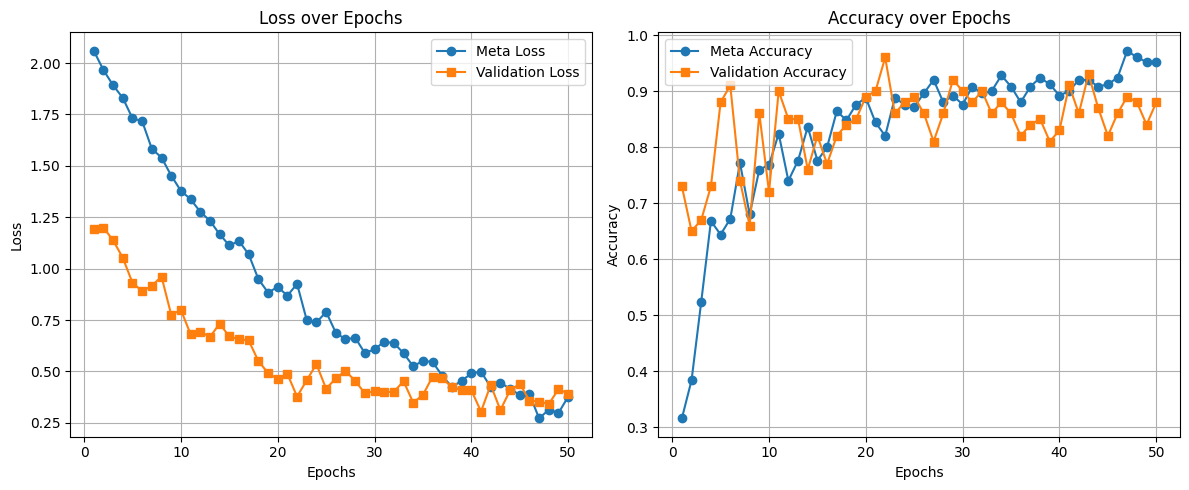

In [22]:
# Create subplots for loss and accuracy
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Plot Meta Loss and Validation Loss
axs[0].plot(range(1, len(meta_loss_list) + 1), [loss.detach().numpy() for loss in meta_loss_list], label="Meta Loss", marker="o")
axs[0].plot(range(1, len(val_loss_list) + 1), val_loss_list, label="Validation Loss", marker="s")
axs[0].set_title("Loss over Epochs")
axs[0].set_xlabel("Epochs")
axs[0].set_ylabel("Loss")
axs[0].legend()
axs[0].grid()

# Plot Meta Accuracy and Validation Accuracy
axs[1].plot(range(1, len(meta_acc_list) + 1), meta_acc_list, label="Meta Accuracy", marker="o")
axs[1].plot(range(1, len(val_acc_list) + 1), val_acc_list, label="Validation Accuracy", marker="s")
axs[1].set_title("Accuracy over Epochs")
axs[1].set_xlabel("Epochs")
axs[1].set_ylabel("Accuracy")
axs[1].legend()
axs[1].grid()

# Show the plot
plt.tight_layout()
plt.show()